In [2]:
import time
import re
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt
import numpy as np
import praw
import nltk

# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('vader_lexicon')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

In [ ]:
# Configuring Reddit API 

R_CLIENT_ID = "YOUR_REDDIT_CLIENT_ID"
R_CLIENT_SECRET = "YOUR_REDDIT_CLIENT_SECRET"
R_USER_AGENT = "SocialJusticeSentiment/1.0"

R_SUBREDDITS = ["socialjustice", "worldnews", "HumanRights", "Palestine", "internationalrelations", "middleeast"]
R_KEYWORDS = [
    "human rights",
    "social justice",
    "refugees",
    "gender equality",
    "racial equality",
    "discrimination",
    "protest",
    "west bank"
]

# Implementing MongoDB for storage
MONGO_URI = "mongodb://localhost:27017/"
MONGO_DB = "social_justice"
MONGO_COLLECTION = "reddit_comments"

STOP_WORDS = set(stopwords.words("english"))
VADER = SentimentIntensityAnalyzer()

In [4]:
def create_reddit_client():
    return praw.Reddit(
        client_id=R_CLIENT_ID,
        client_secret=R_CLIENT_SECRET,
        user_agent=R_USER_AGENT,
    )

def fetch_reddit_comments(
    subreddits,
    keywords=None,
    min_comments=5000,
    post_limit=200,
    use_keywords=False
): 
    reddit = create_reddit_client()
    all_comments = []

    for sub in subreddits:
        print(f"\n Fetching from r/{sub} ...")
        subreddit = reddit.subreddit(sub)

        try:
            # Getting comments from latest, hot and trending posts
            posts = []
            posts.extend(subreddit.hot(limit=post_limit))
            posts.extend(subreddit.new(limit=post_limit))
            posts.extend(subreddit.top(limit=post_limit))

            for post in posts:
                post.comments.replace_more(limit=None)

                for c in post.comments.list():
                    text = getattr(c, "body", "")
                    if not text:
                        continue

                    if use_keywords and keywords:
                        if not any(k.lower() in text.lower() for k in keywords):
                            continue

                    all_comments.append({
                        "source": "reddit",
                        "subreddit": sub,
                        "post_id": post.id,
                        "comment_id": c.id,
                        "text": text,
                        "created_utc": time.strftime(
                            "%Y-%m-%d %H:%M:%S",
                            time.gmtime(c.created_utc)
                        ),
                    })

                    if len(all_comments) >= min_comments:
                        print(f"\n Reached {len(all_comments)} comments — stopping early.")
                        return all_comments

        except Exception as e:
            print(f" Error in r/{sub}: {e}")

        time.sleep(1)  # small delay to be polite to the API

    print(f"\n Finished with {len(all_comments)} comments total.")
    return all_comments

In [5]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS]
    return " ".join(tokens)

def vader_sentiment(text: str) -> str:
    score = VADER.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"

def tb_polarity(text: str) -> float:
    return TextBlob(text).sentiment.polarity

def tb_subjectivity(text: str) -> float:
    return TextBlob(text).sentiment.subjectivity

def tb_sentiment(text: str) -> str:
    """Classify sentiment based on TextBlob polarity."""
    polarity = TextBlob(text).sentiment.polarity

    if polarity >= 0.05:
        return "positive"
    elif polarity <= -0.05:
        return "negative"
    return "neutral"

In [6]:
# Applying Sentiment

def build_dataframe(raw_data):
    df = pd.DataFrame(raw_data)

    # Cleaning
    df["clean_text"] = df["text"].apply(clean_text)

    # Sentiment (VADER + TextBlob)
    df["vader_sentiment"] = df["clean_text"].apply(vader_sentiment)
    df["tb_polarity"] = df["clean_text"].apply(tb_polarity)
    df["tb_subjectivity"] = df["clean_text"].apply(tb_subjectivity)
    df["tb_sentiment"] = df["clean_text"].apply(tb_sentiment)   

    return df

In [7]:
# Saving results to Mongo

def save_to_mongo(df):
    client = MongoClient(MONGO_URI)
    collection = client[MONGO_DB][MONGO_COLLECTION]

    data = df.to_dict(orient="records")
    try:
        collection.insert_many(data, ordered=False)
        print(f" Saved {len(data)} records to MongoDB.")
    except Exception as e:
        print(" Mongo save error:", e)
    finally:
        client.close()

def save_to_csv(df, filename="reddit_output.csv"):
    df.to_csv(filename, index=False)
    print(f" CSV saved: {filename}")

In [8]:
def run_reddit_pipeline():
    print(" Starting Reddit sentiment pipeline...\n")

    raw = fetch_reddit_comments(
        R_SUBREDDITS,
        R_KEYWORDS,
        min_comments=5000,
        post_limit=200,
        use_keywords=False   # Retrieving large dataset 
    )

    print(f"\n Collected {len(raw)} raw comments.")
    
    df = build_dataframe(raw)
    print(f" Processed {df.shape[0]} comments with sentiment labels.")

    save_to_mongo(df)
    save_to_csv(df)

    print("\n Pipeline Successful!")
    return df

In [9]:
df_reddit = run_reddit_pipeline()

 Starting Reddit sentiment pipeline...


 Fetching from r/socialjustice ...
 Error in r/socialjustice: received 429 HTTP response

 Fetching from r/worldnews ...

 Reached 5000 comments — stopping early.

 Collected 5000 raw comments.
 Processed 5000 comments with sentiment labels.
 Saved 5000 records to MongoDB.
 CSV saved: reddit_output.csv

 Pipeline Successful!


In [10]:
df_reddit.head()

,source,subreddit,post_id,comment_id,text,created_utc,clean_text,vader_sentiment,tb_polarity,tb_subjectivity,tb_sentiment
0,reddit,socialjustice,yf88de,iu50xhp,"thanks to mail in voting in Arizona, i already...",2022-10-28 16:27:17,thanks mail voting arizona already mailed ball...,positive,0.2,0.2,positive
1,reddit,socialjustice,1p7yesi,nrjq0f4,While capitalism exists as it does I think wom...,2025-11-30 15:08:10,capitalism exists think woman rights hugely in...,neutral,0.4,0.9,positive
2,reddit,socialjustice,1owbedu,nosenzg,"No discrimination.\n\nHowever, unlike other fo...",2025-11-14 10:46:14,discrimination however unlike forms prejudice ...,positive,0.2,0.7,positive
3,reddit,socialjustice,1ot4am7,no1z0th,# Advocate for concurrent sentencing for Yorri...,2025-11-10 04:18:39,advocate concurrent sentencing yorrie abrahams,negative,0.0,0.0,neutral
4,reddit,socialjustice,1ot4am7,no1z5t8,# [https://c.org/FznMGtPbdY](https://c.org/Fzn...,2025-11-10 04:19:37,,neutral,0.0,0.0,neutral


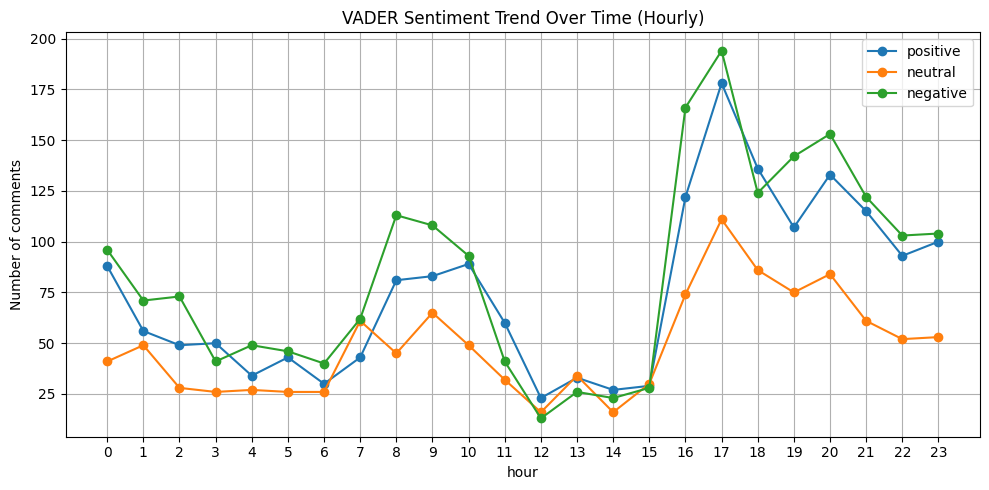

In [11]:
# Identifying trends with time series (by hour of day – batch)

df_reddit["created_utc"] = pd.to_datetime(df_reddit["created_utc"], errors="coerce")
df_reddit["hour"] = df_reddit["created_utc"].dt.hour   # 0–23

sent_trend = (
    df_reddit
    .groupby(["hour", "vader_sentiment"])
    .size()
    .reset_index(name="count")
    .sort_values("hour")
)

plt.figure(figsize=(10,5))

for label in ["positive", "neutral", "negative"]:
    sub = sent_trend[sent_trend["vader_sentiment"] == label]
    if not sub.empty:
        plt.plot(sub["hour"], sub["count"], marker="o", label=label)

plt.title("VADER Sentiment Trend Over Time (Hourly)")
plt.xlabel("hour")
plt.ylabel("Number of comments")
plt.xticks(range(0,24))   
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("vader_hourly_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
df_reddit["tb_sentiment"].value_counts()

tb_sentiment
neutral     2082
positive    1915
negative    1003
Name: count, dtype: int64

In [13]:
df_reddit["vader_sentiment"].value_counts()

vader_sentiment
negative    2031
positive    1802
neutral     1167
Name: count, dtype: int64

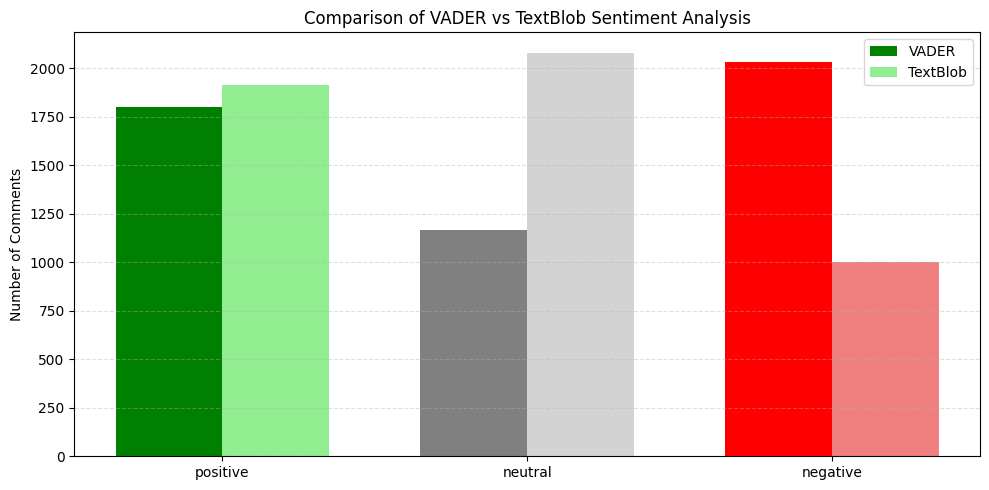

In [15]:
# Get counts
vader_counts = df_reddit["vader_sentiment"].value_counts().reindex(
    ["positive", "neutral", "negative"], fill_value=0
)
tb_counts = df_reddit["tb_sentiment"].value_counts().reindex(
    ["positive", "neutral", "negative"], fill_value=0
)

# Sentiments
labels = ["positive", "neutral", "negative"]

# X positions
x = np.arange(len(labels))
width = 0.35  # width of bars

plt.figure(figsize=(10,5))

# VADER bars
plt.bar(
    x - width/2,
    vader_counts.values,
    width,
    label="VADER",
    color=["green", "grey", "red"]
)

# TextBlob bars
plt.bar(
    x + width/2,
    tb_counts.values,
    width,
    label="TextBlob",
    color=["lightgreen", "lightgrey", "lightcoral"]
)

plt.xticks(x, labels)
plt.ylabel("Number of Comments")
plt.title("Comparison of VADER vs TextBlob Sentiment Analysis")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("combined_sentiment_comparison.png", dpi=300, bbox_inches="tight")
plt.show()